一、流式输出大模型调用结果
 
在介绍Graph的流式输出时，我们提到LangGraph的Graph流式输出有几种不同的模式，其中有一种messages模式，是用来监控大语言模型的Token记录的。这里我们就可以来测试一下。

In [1]:
from config.load_key import load_key
from langchain_community.chat_models import ChatTongyi


# # 直接指定.env路径（根据你的实际路径）
# env_path = Path("E:/Agent_study/LangGraph/config/.env")

# # 加载.env
# load_success = load_dotenv(dotenv_path=env_path)
# print("加载.env是否成功：", load_success)  # 应为True

# # 直接读取API Key
# api_key = os.getenv("BAILIAN_API_KEY")
# print("API Key是否存在：", api_key is not None)  # 应为True
# print("API Key前4位：", api_key[:4] if api_key else "无")  # 应显示sk-a0
# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    model="qwen-plus-2025-07-28",
    api_key=load_key("BAILIAN_API_KEY"),
)

from langgraph.graph import StateGraph, MessagesState, START
from langgraph.checkpoint.memory import InMemorySaver

def call_model(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

graph = builder.compile()

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "湖南的省会是哪里？"}]},
    stream_mode="messages",
):
    print(chunk)

(AIMessageChunk(content='湖南', additional_kwargs={}, response_metadata={}, id='run--74f5a52d-a507-4a4d-9b12-d5f9a287fc8e'), {'langgraph_step': 1, 'langgraph_node': 'call_model', 'langgraph_triggers': ('branch:to:call_model',), 'langgraph_path': ('__pregel_pull', 'call_model'), 'langgraph_checkpoint_ns': 'call_model:4a091888-ac06-480c-23d6-0e82f3bc896c', 'checkpoint_ns': 'call_model:4a091888-ac06-480c-23d6-0e82f3bc896c', 'ls_provider': 'tongyi', 'ls_model_type': 'chat', 'ls_model_name': 'qwen-plus-2025-07-28'})
(AIMessageChunk(content='的省', additional_kwargs={}, response_metadata={}, id='run--74f5a52d-a507-4a4d-9b12-d5f9a287fc8e'), {'langgraph_step': 1, 'langgraph_node': 'call_model', 'langgraph_triggers': ('branch:to:call_model',), 'langgraph_path': ('__pregel_pull', 'call_model'), 'langgraph_checkpoint_ns': 'call_model:4a091888-ac06-480c-23d6-0e82f3bc896c', 'checkpoint_ns': 'call_model:4a091888-ac06-480c-23d6-0e82f3bc896c', 'ls_provider': 'tongyi', 'ls_model_type': 'chat', 'ls_model_na

二、大模型消息持久化
 
和之前介绍LangGraph的Agent相似，Graph也支持构建消息的持久化功能。并且也通常支持通过checkpointer构建短期记忆，以store构建长期记忆。
这里短期记忆和长期记忆，都是可以通过内存或者数据库进行持久化保存的。不过短期记忆更倾向于通过对消息的短期存储，实现多轮对话的效果。而长期记忆则倾向于对消息长期存储后支持语义检索。

In [2]:
from config.load_key import load_key
from langchain_community.chat_models import ChatTongyi
# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    model="qwen-plus",
    api_key=load_key("BAILIAN_API_KEY"),
)

from langgraph.graph import StateGraph, MessagesState, START

from langgraph.checkpoint.memory import InMemorySaver
def call_model(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}

builder = StateGraph(MessagesState)
builder.add_node(call_model)
builder.add_edge(START, "call_model")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {
    "configurable": {
        "thread_id": "1"  # 短期记忆的ID，表示在一个窗口中进行交流
    }
}

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "湖南的省会是哪里？"}]},
    config,
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "湖北呢？"}]},
    config,
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

湖南的省会是哪里？
================================== Ai Message ==================================

湖南省的省会是**长沙市**。
================================ Human Message =================================

湖北呢？
================================== Ai Message ==================================

湖北省的省会是**武汉市**。


三、Human - In - Loop人类干预
 
在LangGraph中也可以通过中断任务，等待确认的方式，来实现过程干预，这样能够更好的减少大语言模型的结果不稳定给任务带来的影响。
 
在具体实现人类干预时，需要注意一下几点：
 
- 必须指定一个checkpointer短期记忆，否则无法保存任务状态。
- 在执行Graph任务时，必须指定一个带有thread_id的配置项，指定线程ID。之后才能通过线程ID，指定恢复线程。
- 在任务执行过程中，通过interrupt()方法，中断任务，等待确认。
- 在人类确认之后，使用Graph提交一个resume=True的Command指令，恢复任务，并继续进行。
 
这种实现方式，在之前介绍LangGraph构建单Agent时已经介绍过，不过，结合Graph的State，在多个Node之间进行复杂控制，这样更能体现出人类监督的价值。

In [6]:
from operator import add

from langchain_core.messages import AnyMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph

from config.load_key import load_key
from langchain_community.chat_models import ChatTongyi
# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    model="qwen-plus",
    api_key=load_key("BAILIAN_API_KEY"),
)

from typing import Literal, TypedDict, Annotated
from langgraph.types import interrupt, Command

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add]

def human_approval(state: State) -> Command[Literal["call_llm", END]]:
    is_approved = interrupt(
        {
            "question": "是否同意调用大语言模型？"
        }
    )

    if is_approved:
        return Command(goto="call_llm")
    else:
        return Command(goto=END)

def call_llm(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(State)
# Add the node to the graph in an appropriate location
# and connect it to the relevant nodes.
builder.add_node("human_approval", human_approval)
builder.add_node("call_llm", call_llm)

builder.add_edge(START,"human_approval")
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)


In [11]:
from langchain_core.messages import HumanMessage

# 提交任务，等待确认
thread_config = {"configurable": {"thread_id": 1}}
graph.invoke({"messages": [HumanMessage("湖南的省会是哪里？")]}, config=thread_config)
# 执行后会中断任务，等待确认

{'messages': [HumanMessage(content='湖南的省会是哪里？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='湖南省的省会是**长沙市**。', additional_kwargs={}, response_metadata={'model_name': 'qwen-plus', 'finish_reason': 'stop', 'request_id': '31adad0c-6564-9684-841b-036a60d16530', 'token_usage': {'input_tokens': 19, 'output_tokens': 9, 'total_tokens': 28, 'prompt_tokens_details': {'cached_tokens': 0}}}, id='run--2015a3a2-2ab5-4885-ac34-ece9fecd0f32-0'),
  HumanMessage(content='湖南的省会是哪里？', additional_kwargs={}, response_metadata={})],
 '__interrupt__': [Interrupt(value={'question': '是否同意调用大语言模型？'}, id='ee13b37344a98053294b66c6a6e4c01c')]}

In [12]:
# 确认同意，继续执行任务
# final_result = graph.invoke(Command(resume=True), config=thread_config)
# print(final_result)
# 不同意，终止任务
final_result = graph.invoke(Command(resume=False), config=thread_config)
print(final_result)

{'messages': [HumanMessage(content='湖南的省会是哪里？', additional_kwargs={}, response_metadata={}), AIMessage(content='湖南省的省会是**长沙市**。', additional_kwargs={}, response_metadata={'model_name': 'qwen-plus', 'finish_reason': 'stop', 'request_id': '31adad0c-6564-9684-841b-036a60d16530', 'token_usage': {'input_tokens': 19, 'output_tokens': 9, 'total_tokens': 28, 'prompt_tokens_details': {'cached_tokens': 0}}}, id='run--2015a3a2-2ab5-4885-ac34-ece9fecd0f32-0'), HumanMessage(content='湖南的省会是哪里？', additional_kwargs={}, response_metadata={})]}


注意
- 任务中断和恢复，需要保持相同的thread_id，通常应用当中都会单独生成一个随机的thread_id，保证唯一的同时，防止其他任务干扰。
- interrupt()方法中断任务的时间不能过长，过长了之后就无法恢复任务了。
- 任务确认时，Command中传递的resume可以是简单的True或False，也可以是一个字典，通过字典可以进行更多的判断。

四、Time Travel时间回溯
由于大语言模型回答问题的不确定性，基于大语言模型构建的应用，也是充满不确定性的。而对于这种不确定性的系统，就有必要进行更精确的检查。当某一个步骤出现问题时，才能及时发现问题，并从发现问题的那个步骤进行重演。为此，LangGraph提供了Time Travel时间回溯功能，可以保存Graph的运行过程，并可以手动指定从Graph的某一个Node开始进行重演。
 
具体实现时，需要注意以下几点：
- 在运行Graph时，需要提供初始的输入消息。
- 运行时，指定thread_id线程ID。并且要基于这个线程ID，再指定一个checkpoint检查点。执行后将在每一个Node执行后，生成一个check_point_id
- 指定thread_id和check_point_id，进行任务重演。重演前，可以选择更新state，当然，如果没问题，也可以不指定。

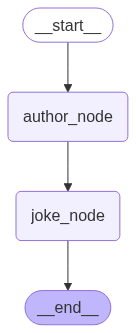

In [14]:
# 构建一个图，图中两个步骤：第一步让大模型推荐第一个有名的作家，第二步，让大模型用推荐的作家的风格写一个100字以内的笑话。
from typing import TypedDict
from typing_extensions import NotRequired
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph

from config.load_key import load_key
from langchain_community.chat_models import ChatTongyi
# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    model="qwen-plus",
    api_key=load_key("BAILIAN_API_KEY"),
)

class State(TypedDict):
    author: NotRequired[str]
    joke: NotRequired[str]

def author_node(state: State):
    prompt = "帮我推荐一位受人们欢迎的作家，只需要给出作家的名字即可。"
    author = llm.invoke(prompt)
    return {"author": author}

def joke_node(state: State):
    prompt = f"用作家：{state['author']} 的风格写一个100字以内的笑话"
    joke = llm.invoke(prompt)
    return {"joke": joke}

builder = StateGraph(State)
builder.add_node("author_node", author_node)
builder.add_node("joke_node", joke_node)

builder.add_edge(START, "author_node")
builder.add_edge("author_node", "joke_node")
builder.add_edge("joke_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [15]:
# 正常执行一个图
import uuid

config = {
    "configurable": {
        "thread_id": uuid.uuid4(),  # 随机的id
    }
}
state = graph.invoke({}, config)

print(state["author"])
print()
print(state["joke"])

content='村上春树' additional_kwargs={} response_metadata={'model_name': 'qwen-plus', 'finish_reason': 'stop', 'request_id': '4b853205-0e7c-91a4-9813-3b376e0acde0', 'token_usage': {'input_tokens': 27, 'output_tokens': 4, 'total_tokens': 31, 'prompt_tokens_details': {'cached_tokens': 0}}} id='run--7decf815-e288-42a2-93c3-2be1459e4377-0'

content='村上春树风格的笑话：\n\n深夜两点，我还在给冰箱里的牛奶写读后感。猫说：“你已经盯着它三小时了。”我说：“它也在审视我。”这时冰箱突然开口：“你们俩够了，谁来把我关上？”' additional_kwargs={} response_metadata={'model_name': 'qwen-plus', 'finish_reason': 'stop', 'request_id': 'ab394f35-27c7-9ac2-ac23-eafb5237da9b', 'token_usage': {'input_tokens': 172, 'output_tokens': 54, 'total_tokens': 226, 'prompt_tokens_details': {'cached_tokens': 0}}} id='run--ccab5bc0-c4d7-4d98-9eb4-88883e9cd818-0'


In [16]:
# 查看所有Checkpoint检查点
states = list(graph.get_state_history(config))

for state in states:
    print(state.next)
    print(state.config["configurable"]["checkpoint_id"])
    print()

()
1f0712cd-038c-6234-8002-90c95a5ff90f

('joke_node',)
1f0712cc-ee9e-67b1-8001-917062f37590

('author_node',)
1f0712cc-80d7-60c6-8000-6e7b5a59f8d2

('__start__',)
1f0712cc-80d4-625b-bfff-0e04994b7402



In [17]:
# 选定某一个检查点，这里选择author_node，让大模型重新推荐作家
selected_state = states[1]
print(selected_state.next)
print(selected_state.values)

('joke_node',)
{'author': AIMessage(content='村上春树', additional_kwargs={}, response_metadata={'model_name': 'qwen-plus', 'finish_reason': 'stop', 'request_id': '4b853205-0e7c-91a4-9813-3b376e0acde0', 'token_usage': {'input_tokens': 27, 'output_tokens': 4, 'total_tokens': 31, 'prompt_tokens_details': {'cached_tokens': 0}}}, id='run--7decf815-e288-42a2-93c3-2be1459e4377-0')}


In [18]:
# 为了后面的重演，更新state, 可选步骤
new_config = graph.update_state(selected_state.config, values={"author": "郭德纲"})
print(new_config)

{'configurable': {'thread_id': '2ba24b15-0b02-493c-8967-23b51b632e66', 'checkpoint_ns': '', 'checkpoint_id': '1f0712e0-8d0d-66a6-8002-bd1411d396a4'}}


In [19]:
# 接下来，指定thread_id和checkpoint_id，进行重演
graph.invoke(None, new_config)

{'author': '郭德纲',
 'joke': AIMessage(content='话说那天我跟于谦老师去菜市场，我说：“于老师，您买这菜咋跟捡钱似的？”  \n他回我：“你懂什么，这叫精打细算过日子！”  \n我说：“那我以后不说您了，说您持家有道。”  \n于是一路走一路夸，结果走到鱼摊前，他掏出手机：“来，扫码，无现金支付更环保。”  \n我一看，好么，环保袋里装着三条鲫鱼，还带着两棵葱。', additional_kwargs={}, response_metadata={'model_name': 'qwen-plus', 'finish_reason': 'stop', 'request_id': '0349910d-0c7a-990e-b3a6-8c4c8cee52d4', 'token_usage': {'input_tokens': 29, 'output_tokens': 111, 'total_tokens': 140, 'prompt_tokens_details': {'cached_tokens': 0}}}, id='run--499fa8e0-fd67-419f-a736-ac4c46232f96-0')}